# Project 01: Environmental Air Quality Analysis

## Notebook 01: Initial Data Exploration

### Goal
The goal of this notebook is to load the dataset, understand its structure, inspect data quality, and identify the first questions for analysis.

### Questions
1. How many rows and columns does the dataset have?
2. What does each column represent?
3. Are there missing values?
4. What are the data types?
5. Are there unusual or suspicious values?

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [148]:
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.1.4
numpy version: 1.26.4


In [149]:
import os

print("Current directory:")
print(os.getcwd())

Current directory:
/Users/jaeyeonhan/Projects_JYH/DataScience-Journey/Projects/01_project_environmental_air_quality_analysis/notebooks


In [150]:
print("Files here:")
print(os.listdir())

Files here:
['Air Pollution Analysis.ipynb']


In [151]:
df = pd.read_csv("../data/global_air_quality_data_10000.csv")

In [152]:
df.shape

(10000, 12)

In [153]:
df.head()
# a quick preview.

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


In [154]:
df.columns
# exactly the variable names.

Index(['City', 'Country', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'Temperature', 'Humidity', 'Wind Speed'],
      dtype='object')

In [155]:
df.info()
# variable names plus data types and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         10000 non-null  object 
 1   Country      10000 non-null  object 
 2   Date         10000 non-null  object 
 3   PM2.5        10000 non-null  float64
 4   PM10         10000 non-null  float64
 5   NO2          10000 non-null  float64
 6   SO2          10000 non-null  float64
 7   CO           10000 non-null  float64
 8   O3           10000 non-null  float64
 9   Temperature  10000 non-null  float64
 10  Humidity     10000 non-null  float64
 11  Wind Speed   10000 non-null  float64
dtypes: float64(9), object(3)
memory usage: 937.6+ KB


In [156]:
df.isna().sum()
# to find missing value

City           0
Country        0
Date           0
PM2.5          0
PM10           0
NO2            0
SO2            0
CO             0
O3             0
Temperature    0
Humidity       0
Wind Speed     0
dtype: int64

In [157]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,77.448439,104.438161,52.198649,25.344490,5.047984,106.031643,14.89715,55.078579,10.231636
std,41.927871,55.062396,27.320490,14.091194,2.852625,55.081345,14.44380,25.982232,5.632628
min,5.020000,10.000000,5.010000,1.000000,0.100000,10.040000,-10.00000,10.010000,0.500000
25%,41.185000,57.137500,28.347500,13.190000,2.560000,58.380000,2.25750,32.527500,5.290000
50%,77.725000,103.690000,52.100000,25.350000,5.090000,106.055000,14.75500,55.080000,10.260000
75%,113.392500,152.265000,75.705000,37.500000,7.480000,153.982500,27.38250,77.442500,15.070000
max,149.980000,200.000000,100.000000,49.990000,10.000000,200.000000,40.00000,99.990000,20.000000


In [158]:
city_pm25 = df.groupby("City")["PM2.5"].mean()


len(city_pm25), city_pm25

(20,
 City
 Bangkok           77.461483
 Beijing           78.627848
 Berlin            76.974277
 Cairo             76.888451
 Dubai             80.013692
 Istanbul          77.711220
 Johannesburg      77.666008
 London            77.614908
 Los Angeles       76.418169
 Madrid            75.434768
 Mexico City       78.855054
 Moscow            77.878610
 Mumbai            78.901167
 New York          77.857054
 Paris             74.694622
 Rio de Janeiro    75.669532
 Seoul             74.802471
 Sydney            78.933560
 Tokyo             78.867475
 Toronto           77.827645
 Name: PM2.5, dtype: float64)

In [159]:
city_pm25.sort_values(ascending=False)

City
Dubai             80.013692
Sydney            78.933560
Mumbai            78.901167
Tokyo             78.867475
Mexico City       78.855054
Beijing           78.627848
Moscow            77.878610
New York          77.857054
Toronto           77.827645
Istanbul          77.711220
Johannesburg      77.666008
London            77.614908
Bangkok           77.461483
Berlin            76.974277
Cairo             76.888451
Los Angeles       76.418169
Rio de Janeiro    75.669532
Madrid            75.434768
Seoul             74.802471
Paris             74.694622
Name: PM2.5, dtype: float64

In [160]:
city_pollution = df.groupby("City")[["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]].mean()

In [161]:
city_pollution.sort_values(by = "PM2.5",ascending=False)



,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,
Dubai,80.013692,103.891192,52.683038,24.964096,5.084346,106.395673
Sydney,78.933560,103.373951,52.474938,25.684033,5.023477,106.818436
Mumbai,78.901167,105.841667,53.344074,25.029444,5.077556,106.643648
Tokyo,78.867475,105.040937,52.672770,27.978635,5.101446,108.479491
Mexico City,78.855054,104.526868,50.863650,26.022138,5.141339,105.686285
Beijing,78.627848,103.189877,51.621045,24.903258,5.093443,105.740225
Moscow,77.878610,105.936286,52.029876,26.110913,5.120996,107.294212
New York,77.857054,102.950538,51.001634,25.168903,4.987591,106.371849
Toronto,77.827645,103.867799,51.546834,24.802027,4.946544,110.850367


In [162]:
[type(city_pm25), 
type(city_pollution)]
#series: one column, df: multiple columns

[pandas.core.series.Series, pandas.core.frame.DataFrame]

(72.0, 82.0)

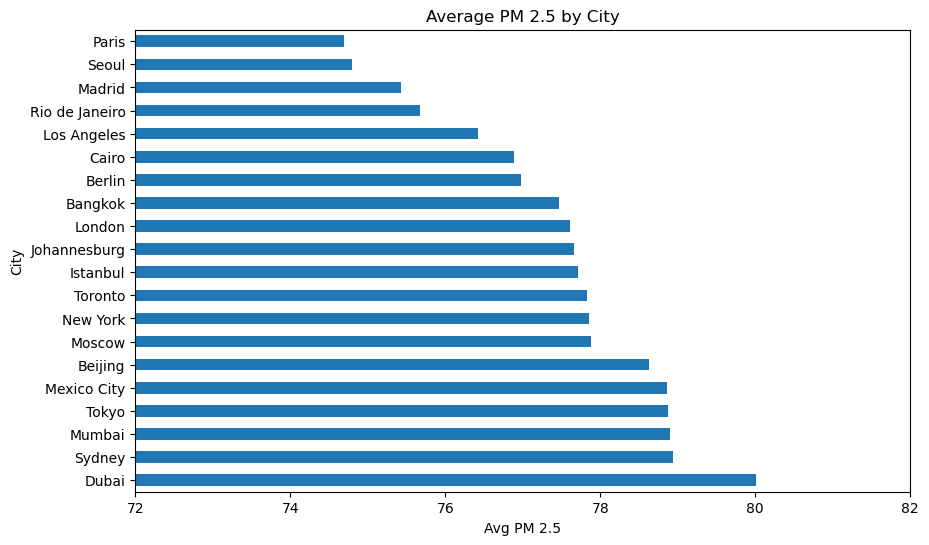

In [163]:
pm25bar = city_pm25.sort_values(ascending=False).plot(kind="barh",
                                                      figsize=(10,6)
)
plt.title("Average PM 2.5 by City")
plt.ylabel("City")
plt.xlabel("Avg PM 2.5")
plt.xlim(72, 82)

# Log

## Observation 1
    The dataset contains 10,000 observations (rows) and 12 variables (columns). Each row represents one air quality record, while each column describes one characteristic of that record, such as city, PM2.5, temperature, or humidity.

## Observation 2
The dataset contains information about:
- City
- Country
- Date
- PM2.5
- PM10
- NO2
- SO2
- CO
- O3
- Temperature
- Humidity
- Wind Speed

The dataset contains measurements collected from 20 different cities worldwide.

## Question

Which cities consistently experience the highest PM2.5 concentration?

## Why does this matter?

Identifying highly polluted cities can help prioritize environmental interventions and public health policies.

### Interpretation

A horizontal bar chart sorted by average PM2.5 will make it easier to compare pollution levels across cities.

Sorting the cities from highest to lowest allows readers to immediately identify the cities with the highest and lowest average PM2.5 concentrations.

This visualization supports the business objective of identifying cities that may require greater environmental attention.

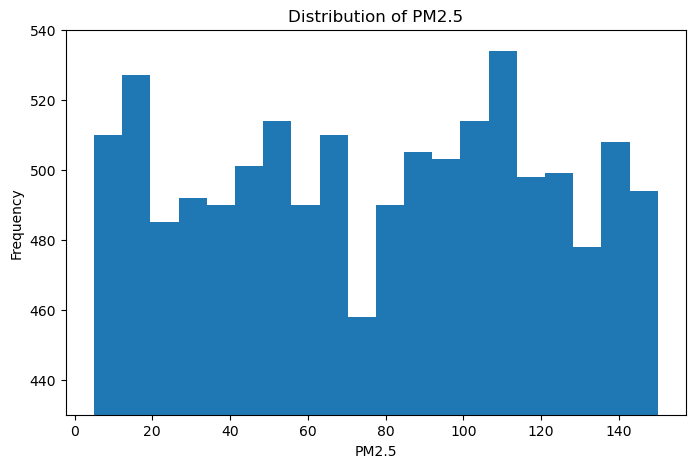

In [164]:
# using Histogram

df["PM2.5"].plot(
    kind="hist",
    bins=20,
    figsize=(8,5)
)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.ylim(430, 540)
plt.show()

In [ ]:
df["PM2.5"].plot(
    kind="boxplot",
    bins=20,
    figsize=(8,5)
)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.ylim(430, 540)
plt.show()



ValueError: box plot is not a valid plot kind

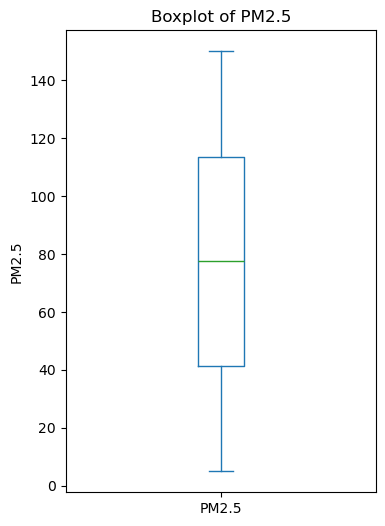

In [ ]:
df["PM2.5"].plot(
    kind="box",
    figsize=(4,6)
)

plt.title("Boxplot of PM2.5")
plt.ylabel("PM2.5")
plt.show()

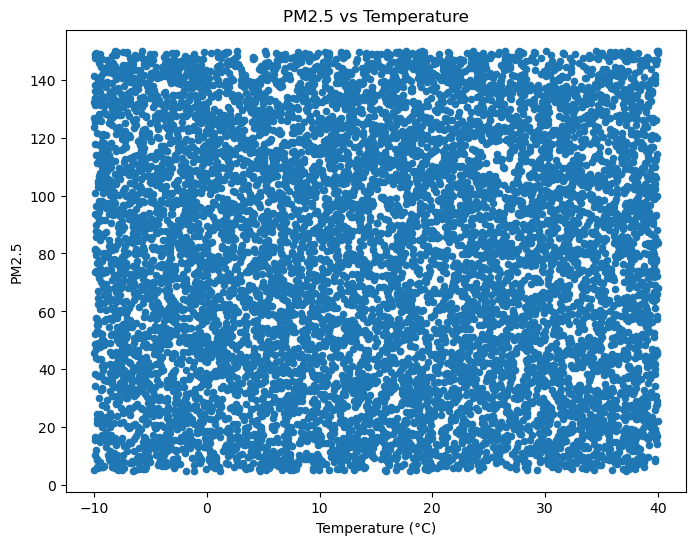

In [ ]:
# 1. PM2.5 vs Temperature

df.plot(
    kind="scatter",
    x="Temperature",
    y="PM2.5",
    figsize=(8,6)
)

plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5")
plt.show()

In [ ]:
df["PM2.5"].corr(df["Temperature"])
### The correlation coefficient between PM2.5 and temperature was -0.0119, 
# indicating virtually no linear relationship between the two variables. 
# Although the coefficient is slightly negative, 
# its magnitude is extremely close to zero,suggesting no meaningful association.

-0.01194529364412359

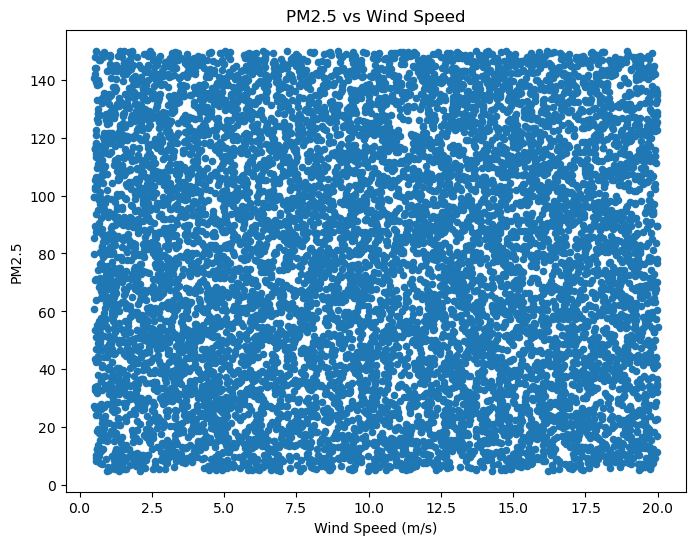

In [ ]:
#PM2.5 vs Wind Speed
df.plot(
    kind="scatter",
    x="Wind Speed",
    y="PM2.5",
    figsize=(8,6)
)

plt.title("PM2.5 vs Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5")
plt.show()


In [ ]:
df["PM2.5"].corr(df["Wind Speed"])

-0.0017697659418546613

In [ ]:
df["Date"].head()

0    2023-03-19
1    2023-02-16
2    2023-11-13
3    2023-03-16
4    2023-04-04
Name: Date, dtype: object

In [ ]:
df["Date"].max()

'2023-12-28'

In [ ]:
df["Date"].min()

'2023-01-01'

In [ ]:
df.dtypes

City            object
Country         object
Date            object
PM2.5          float64
PM10           float64
NO2            float64
SO2            float64
CO             float64
O3             float64
Temperature    float64
Humidity       float64
Wind Speed     float64
dtype: object

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

City                   object
Country                object
Date           datetime64[ns]
PM2.5                 float64
PM10                  float64
NO2                   float64
SO2                   float64
CO                    float64
O3                    float64
Temperature           float64
Humidity              float64
Wind Speed            float64
dtype: object

In [ ]:
df["Month"] = df["Date"].dt.month

In [ ]:
top5 = city_pm25.sort_values(ascending=False).head(5).index
df_top5 = df[df["City"].isin(top5)]

In [ ]:
monthly_pm25 = (
    df_top5
    .groupby(["City", "Month"])["PM2.5"]
    .mean()
)
monthly_pm25.head(10)

City   Month
Dubai  1        70.994706
       2        67.774737
       3        83.787619
       4        72.613571
       5        80.642708
       6        77.688974
       7        87.473571
       8        87.187429
       9        75.362632
       10       84.951000
Name: PM2.5, dtype: float64

In [ ]:
monthly_pm25 = monthly_pm25.reset_index() 

In [ ]:
monthly_pm25 = monthly_pm25.pivot(
    index="Month", # Make Month the rows.
    columns="City", # Make each city its own column.
    values="PM2.5" # Fill the table with PM2.5 values.
)

KeyError: 'City'